# Multivariate Forward Selection guiado por complejidad

En este notebook vamos a analizar los resultados que obtenemos cuando hacemos un forward selection con cada una de las medidas de complejidad de estudio (Hostility, kDN, N1). Los pasos que hemos seguido son:
- Estudiamos la complejidad univariante con cada feature.
- Establecemos un ranking en base a dichos valores univariantes.
- En función del ranking logrado cada medida de complejidad, vamos metiendo variables de una en una y evaluando la complejidad.
- Hacemos un gráfico que muestre cómo va cambiando la complejidad según aumenta el número de variables. La idea es observar un codo (como en el knee plot de las k-means) que indique que ya no merece la pena seguir añadiendo variables debido a la escasa reducción de la complejidad.

In [1]:
import copy
from sklearn import preprocessing
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.feature_selection import mutual_info_classif, f_classif
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_predict, StratifiedKFold
from skrebate import ReliefF
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import glob
import re
# from UnivariateInstanceComplexityAnalysis_Code import *
# from All_measures import *
from ForwardComplexity_UnivariateRanking import *

In [2]:
import os
os.chdir("..")
root_path = os.getcwd()

In [3]:
# csv_file = "Results_ForwardComplexity/ArtificialDataset16_forward_dataset_classes.csv"
# df_forward = load_forward_selection_results(csv_file)
# plot_forward_complexity(df_forward, dataset_name="ArtificialDataset16")

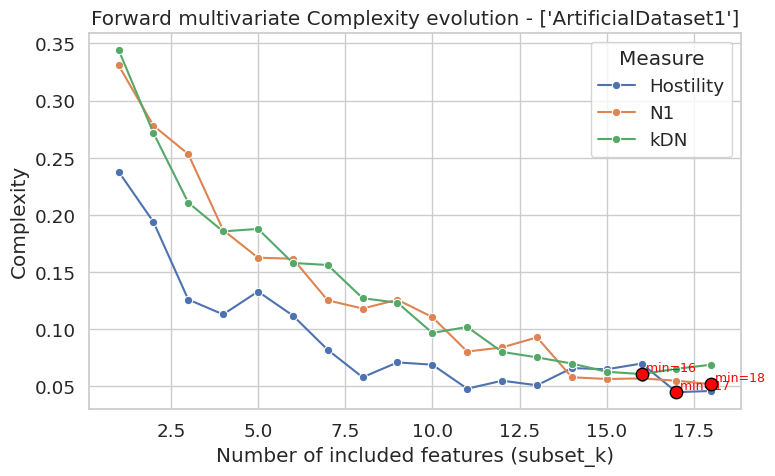

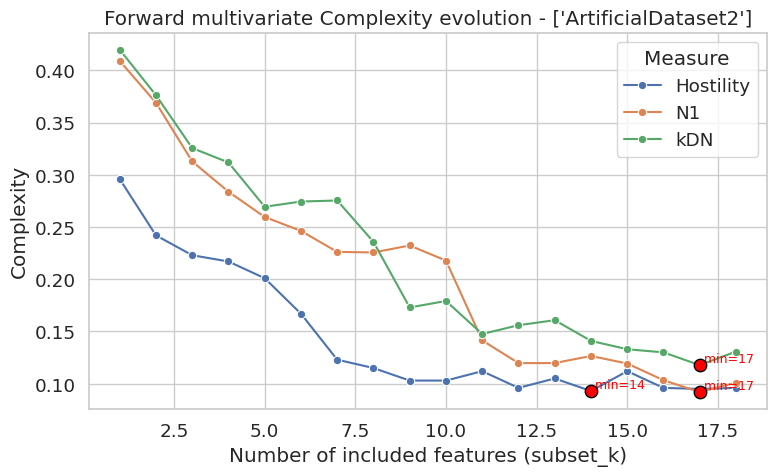

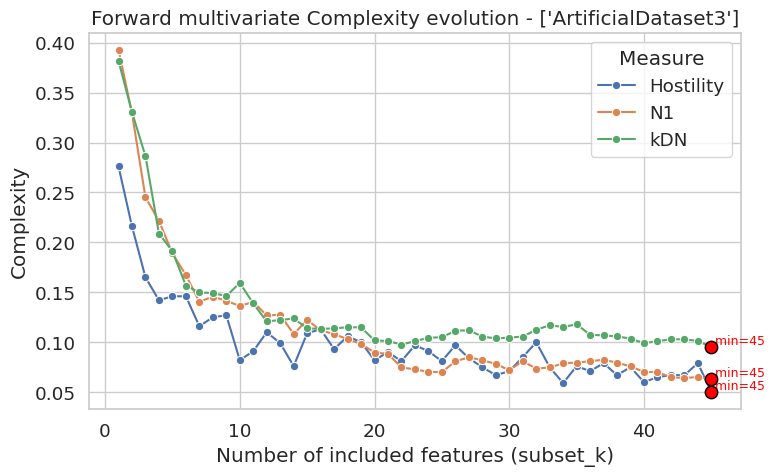

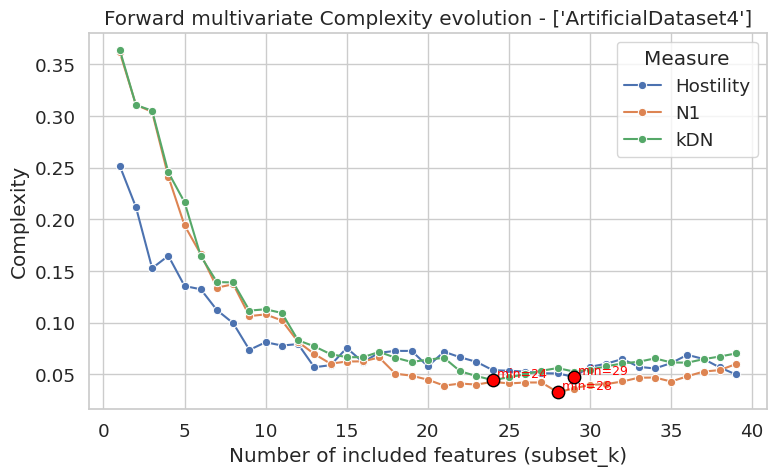

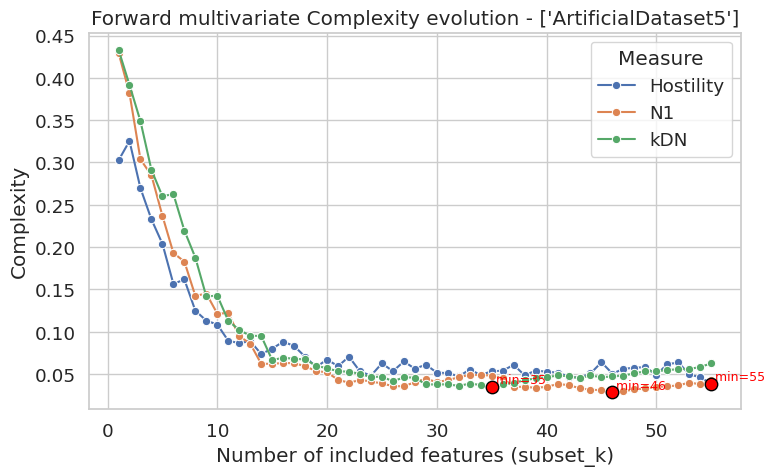

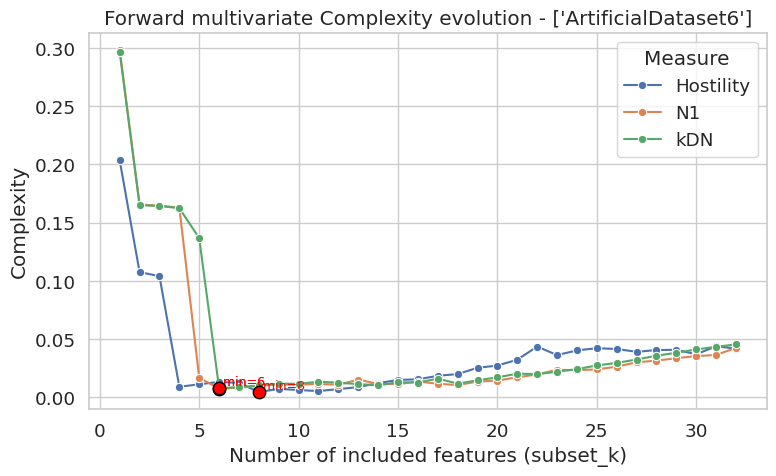

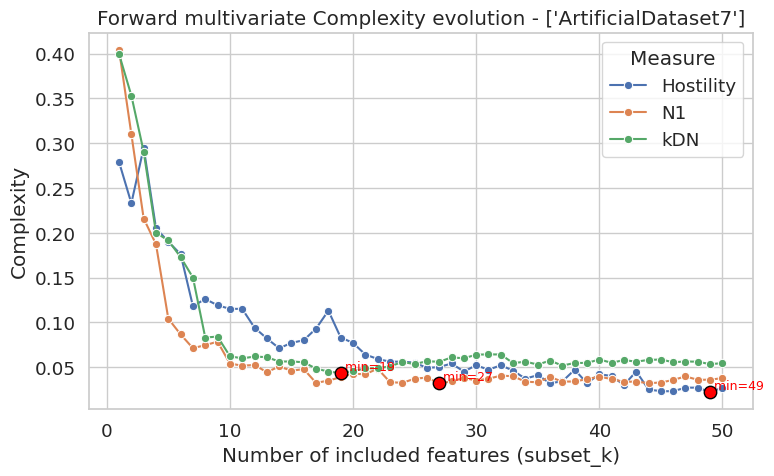

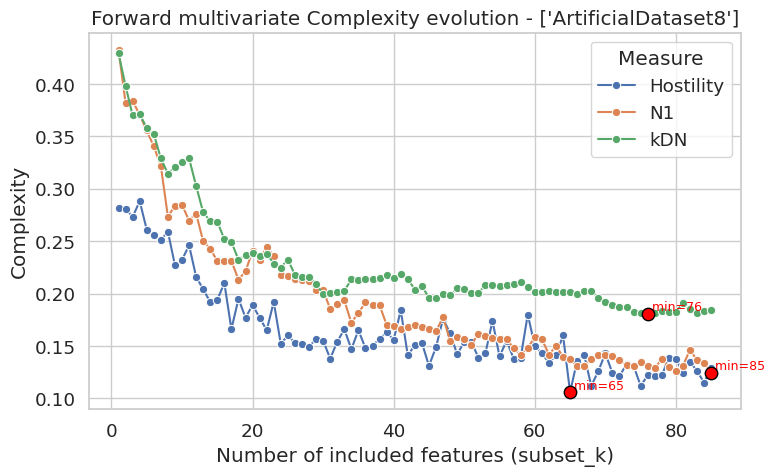

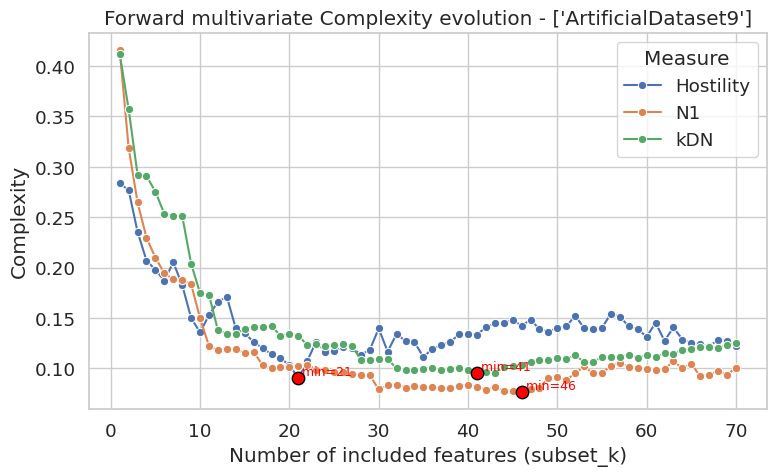

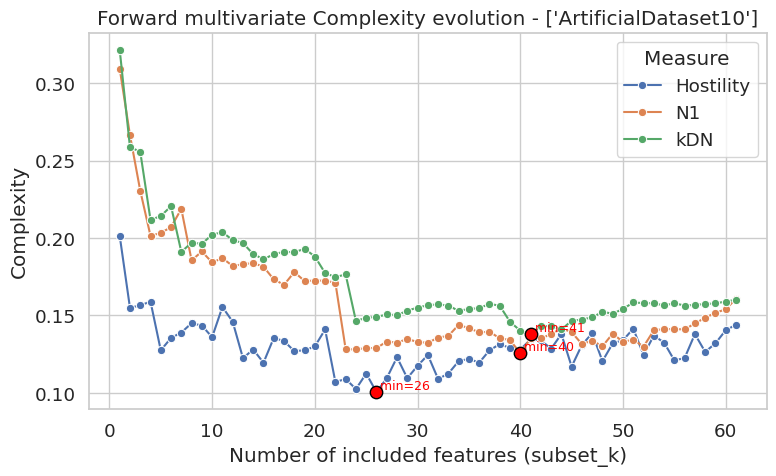

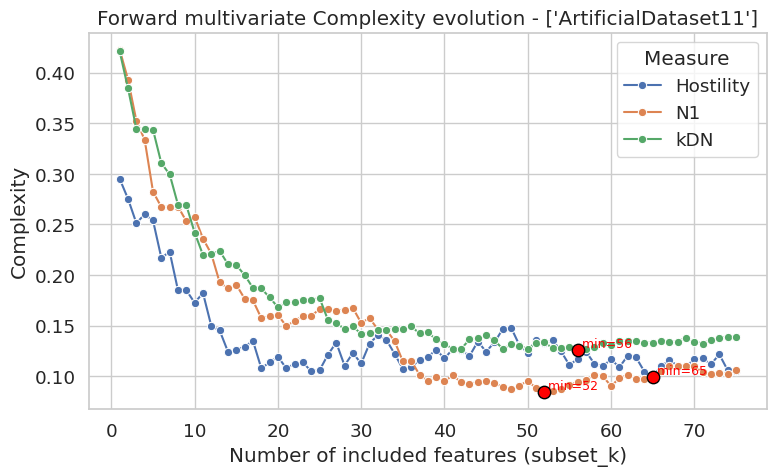

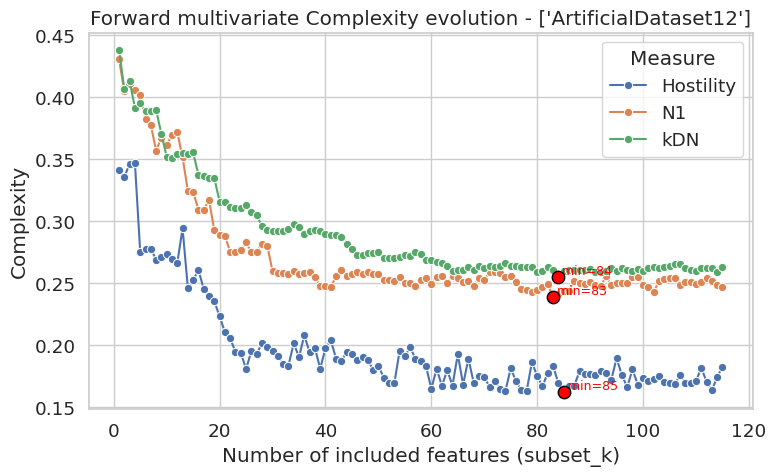

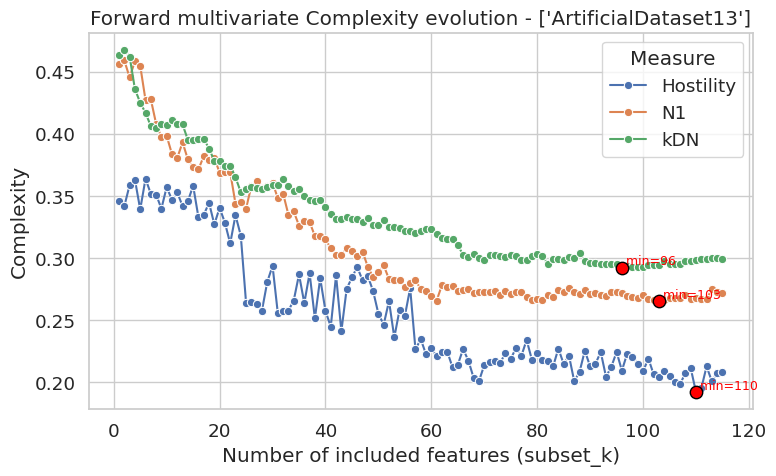

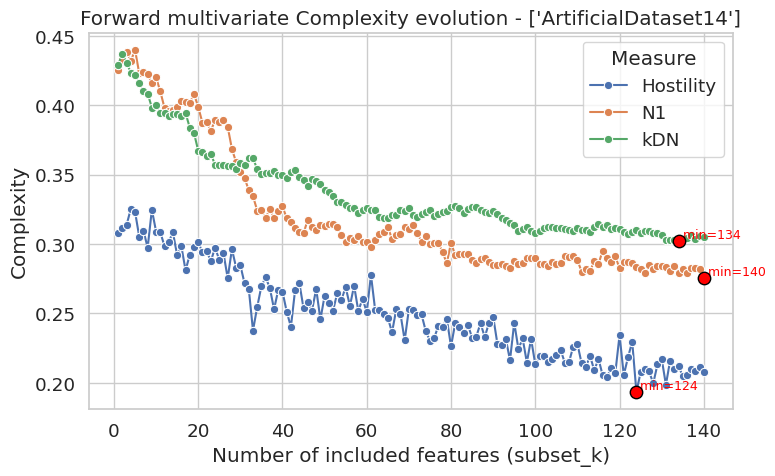

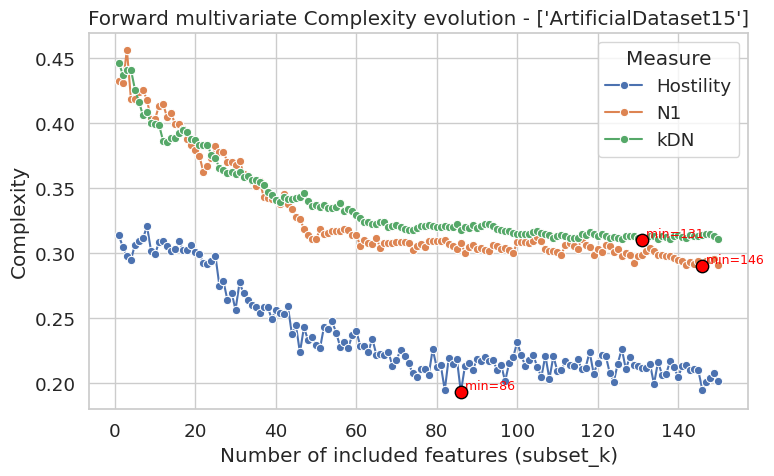

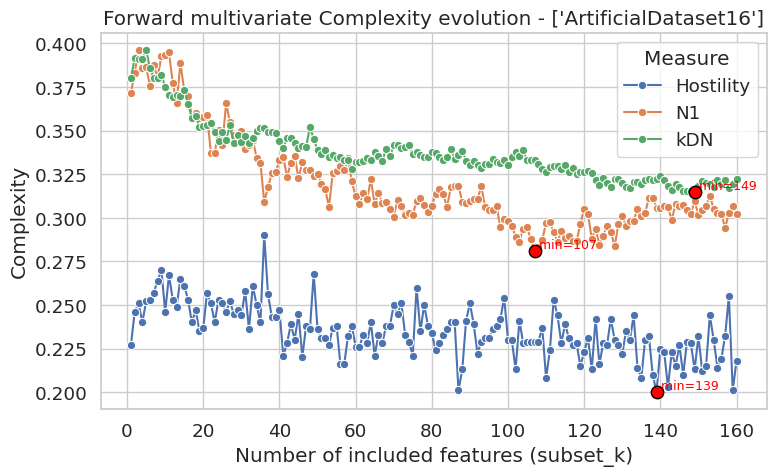

In [4]:
# Leer todos los comparison.csv de la carpeta
files = glob.glob("Results_ForwardComplexity/*_forward_dataset_classes.csv")
files = sorted(files,key=lambda f: int(re.search(r"ArtificialDataset(\d+)_", f).group(1)))
figsize = (8,5)
for f in files[:16]:
    df_forward = load_forward_selection_results(f)
    dataset_name = [re.search(r"/([^/_]+)_", f).group(1)]
    plot_forward_complexity(df_forward, dataset_name=dataset_name,figsize=figsize)

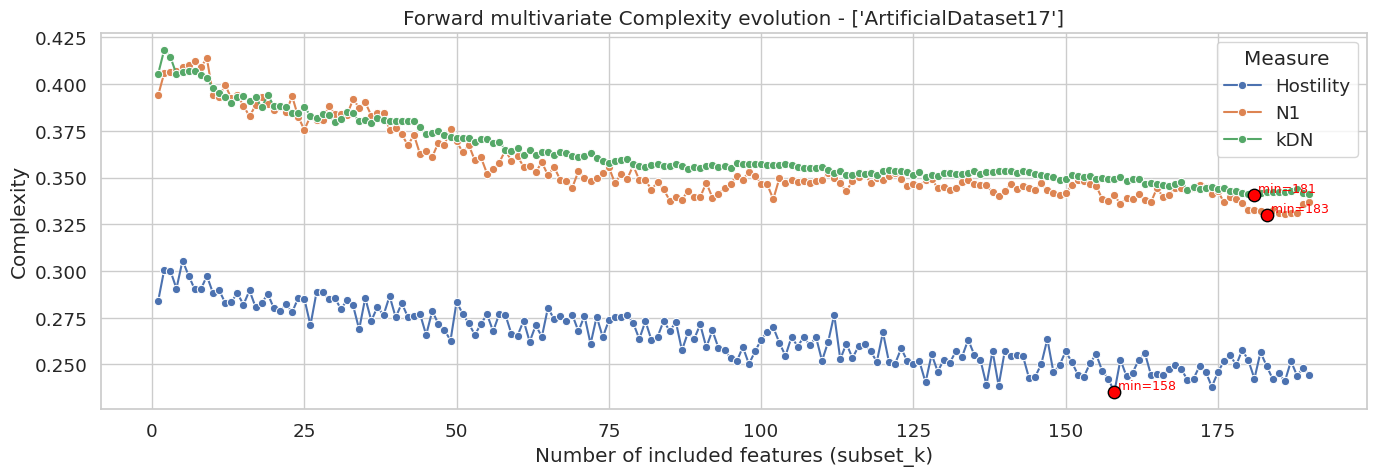

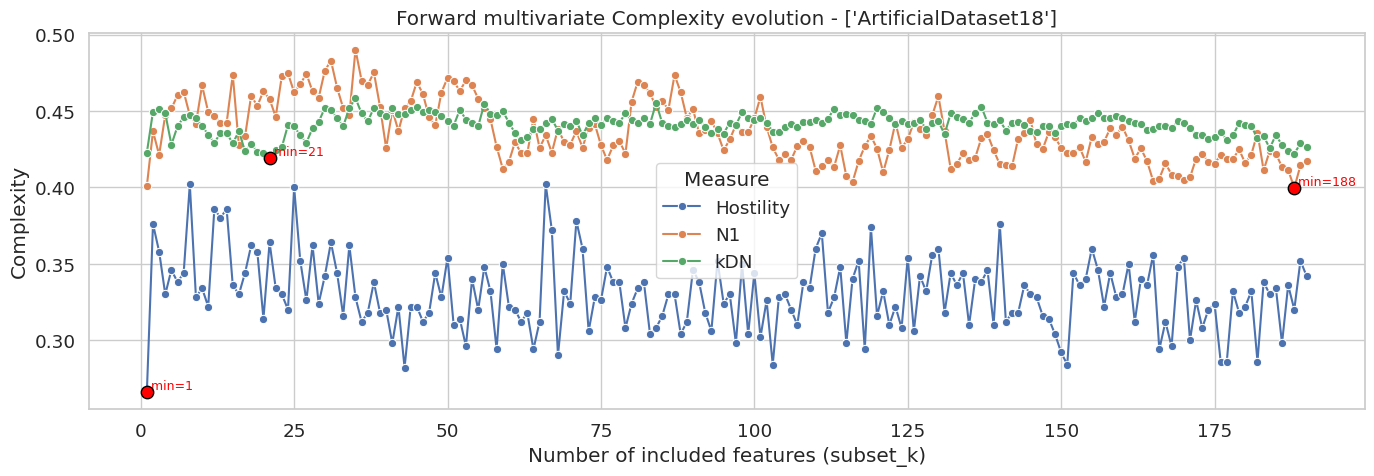

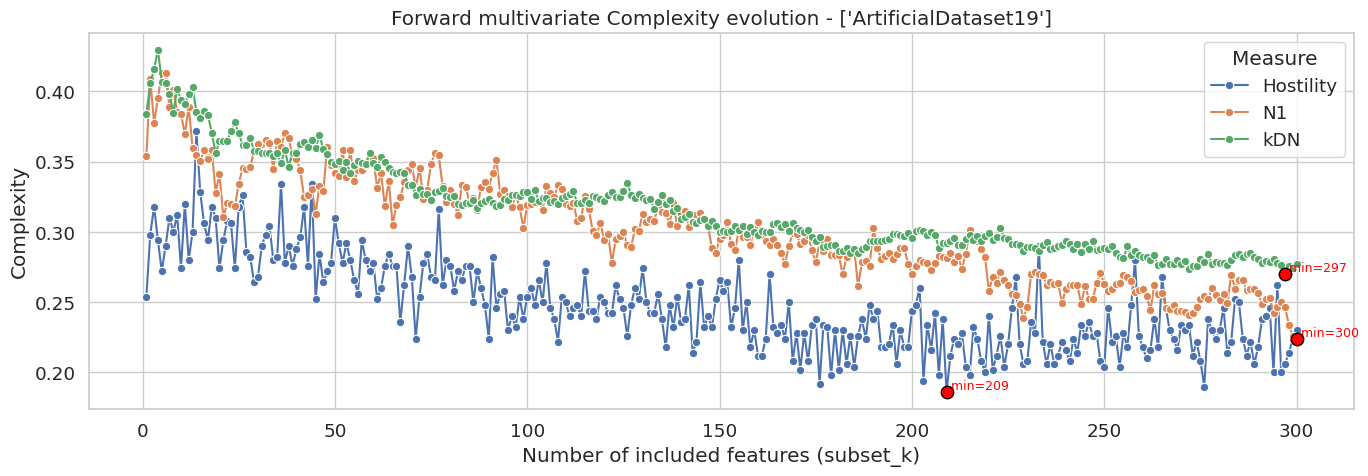

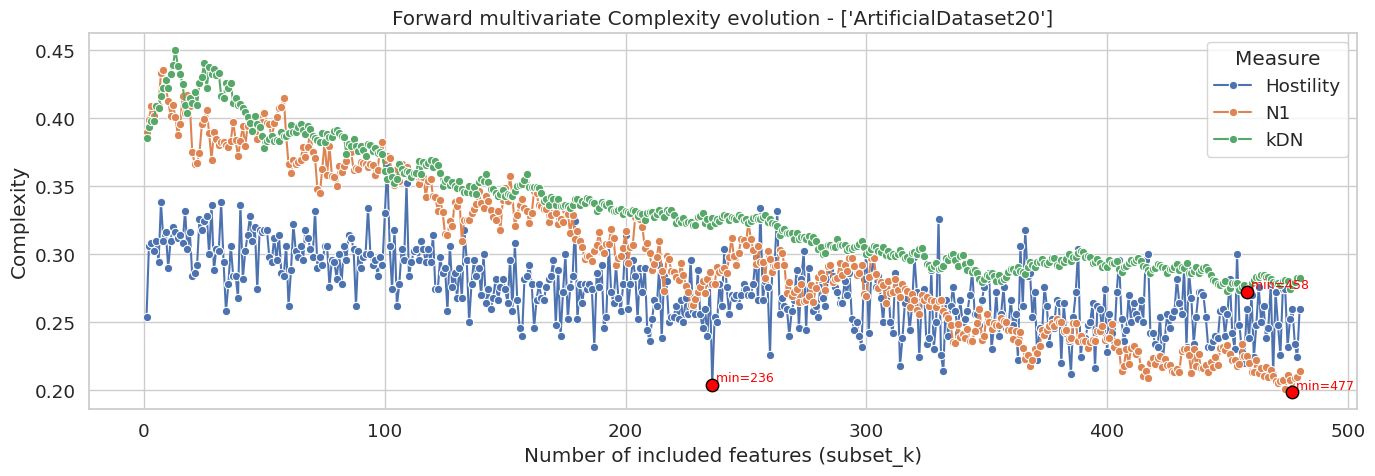

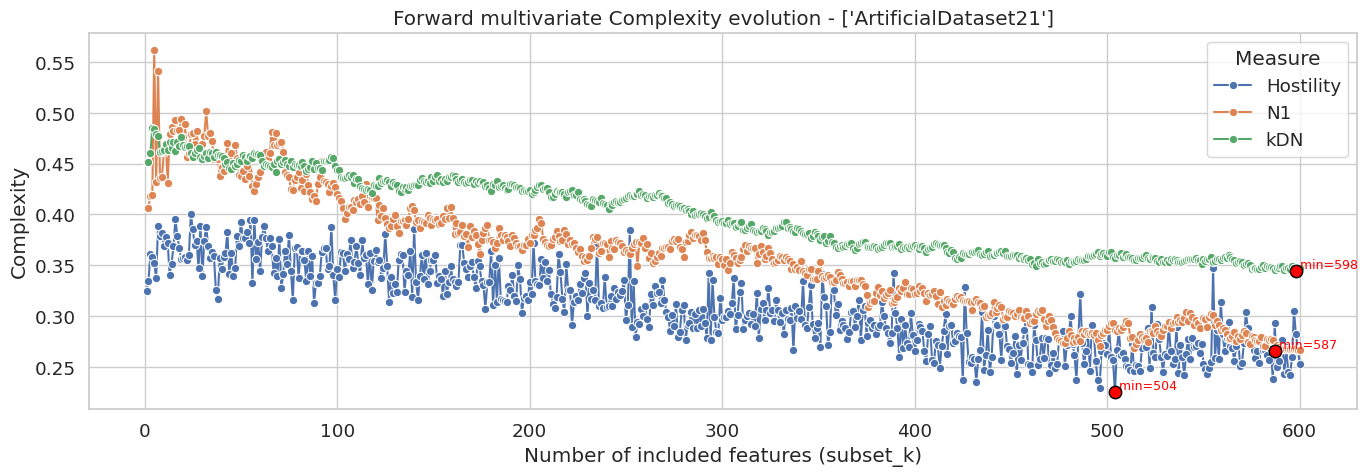

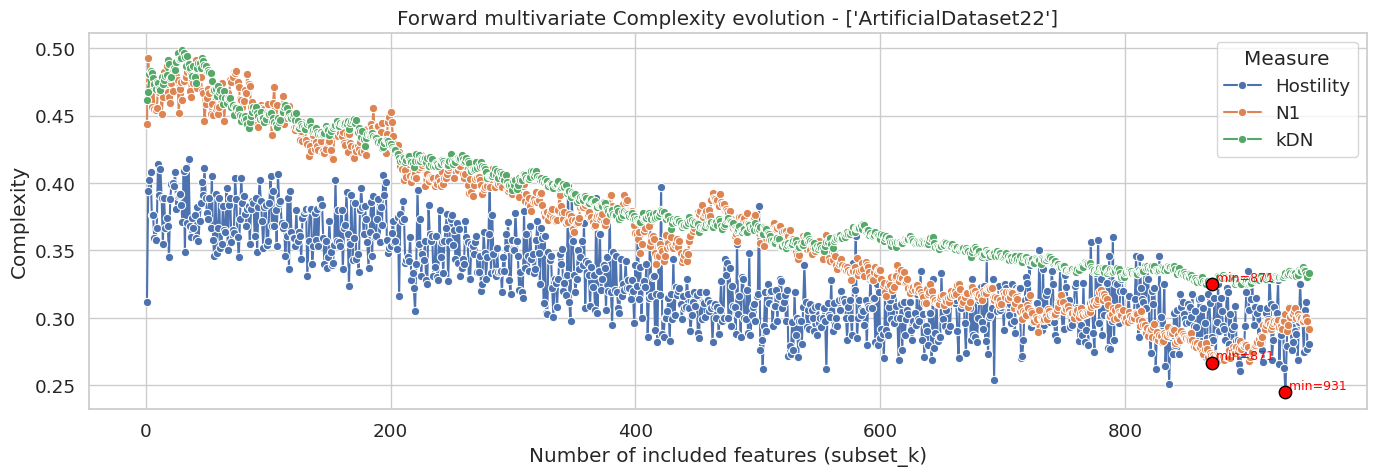

In [6]:
figsize = (14,5)
for f in files[16:]:
    df_forward = load_forward_selection_results(f)
    dataset_name = [re.search(r"/([^/_]+)_", f).group(1)]
    plot_forward_complexity(df_forward, dataset_name=dataset_name, figsize=figsize)

En general sí que se aprecia tendencia decreciente y se puede localizar un codo. Es más fácil de identificar en los conjuntos con pocas variables porque salen menos puntitos en el gráfico. También ees más difícil observarlos cuando los datasets son muy complejos (solapamiento, lío de clases, imbalanced, etc.).

También observo que en los datasets con muchas variables, aunque sean sencillos, simplemente se aprecia una tendencia lineal decreciente sin patrón particular. Es decir, cuesta más encontrar el codo o ese corte de variables. Creo que puede ser porque esos datasets realmente no tengan mucha lógica, es decir, un dataset en el que sean necesarias/informativas 300 variables? En las cosas que veo del estado del arte, eel subconjunto final de variables suele ser menor. --> HACER EXPERIMENTO DE REDUCIR NÚMERO DE VARIABLES PARA VER RENDIMIENTO DE MODELOS EN ESTOS CASOS (ESTO YA DEBERÍAMOS VERLO EN LOS RESULTADOS DE CLASIFICACIÓN DEL FORWARD).